The goal of this notebook is to study the coauthorship network of the BJP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import aquarel
sns.set_palette("viridis")

plt.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,  # Latex
    "font.serif": ["Computer Modern Roman"],  # ou "Times New Roman"
})

In [2]:
import graphistry
graphistry.register(api=3, protocol='https', server='hub.graphistry.com', personal_key_id="L97MZMMRMW", personal_key_secret="X6U4U2UTL76RGMN2")

In [3]:
import networkx as nx

In [4]:
works = pd.read_csv("data/works/works_abstracts.csv")
works = works[works["year"] != 2025]

for index, article in works.iterrows():
    works.loc[index, "authors_count"] = 0
    if pd.isna(article["author_1"]):
        continue
    i = 1
    while pd.notna(article.get(f"author_{i}")):
        i += 1
    works.loc[index, "authors_count"] = i - 1

C:\Users\gabri\AppData\Local\Temp\ipykernel_22456\1575678616.py:1: DtypeWarning: Columns (92,93,94,95,96,97,98,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,204,205,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,344,345,346,347,348,349,350,351,3

# Simplified network

Network in which only the first author is linked with the other authors

In [8]:
#nodes = pd.DataFrame({"Id": [], "Label": []})
edges =[]

for index, article in works.iterrows():
    if pd.isna(article["author_1"]):
         continue
    source = article["author_1"]
    i = 2
    while (i < 100) and pd.notna(article.get(f"author_{i}")):
         new = {
              "Source" : source,
              "Target" : article[f"author_{i}"],
              "Type" : "Undirected"
         }
         edges.append(new)
         i += 1
edges = pd.DataFrame(edges)

In [10]:
edges.head()

,Source,Target,Type
0,https://openalex.org/A5053584746,https://openalex.org/A5087656450,Undirected
1,https://openalex.org/A5053584746,https://openalex.org/A5004753412,Undirected
2,https://openalex.org/A5053584746,https://openalex.org/A5019284502,Undirected
3,https://openalex.org/A5053584746,https://openalex.org/A5042962646,Undirected
4,https://openalex.org/A5109933717,https://openalex.org/A5114172798,Undirected


In [12]:
edges = edges[edges["Target"].notna()]

In [ ]:
edges.to_csv("data/works/edges_clean.csv", index=False)

In [26]:
edges = pd.read_csv("./data/works/edges/edges_clean.csv")

### Visualization

In [28]:
g = graphistry.edges(edges, "Source", "Target")

In [ ]:
g = graphistry.edges(edges, "Source", "Target")
g.plot()

### Countries

In [13]:
edges =[]

for index, article in works.iterrows():
    if pd.isna(article["author_1"]):
         continue
    source = article["author_1"]
    country_source = article["country_1"]
    i = 2
    while (i < 100) and pd.notna(article.get(f"author_{i}")):
         if country_source != article[f"country_{i}"]:
          new = {
               "Source" : source,
               "Target" : article[f"author_{i}"],
               "Type" : "Undirected",
               "Country_Source" : country_source,
               "Country_Target" : article[f"country_{i}"],
               "Date" : article["year"] #+ ", 2024]>"
          }
          edges.append(new)
         i += 1
edges = pd.DataFrame(edges)

In [134]:
edges = edges[edges["Country_Source"].notna()]
edges = edges[edges["Country_Target"].notna()]
edges["compteur"] = 1
edges["now"] = 2025

In [137]:
edges = edges[["Source", "Target", "Date", "now"]]
edges.columns = ["Source", "Target", "year", "now"]

In [139]:
edges.to_csv("test2.csv", index = False)

# Complete network

it may be interesting to keep the direction of the edges: the direction indicate the importance of the author in the article, the arrow goes from the better positioned author to the worse positioned one in the couple. 

In [5]:
edges =[]

for index, article in works.iterrows():
    n = 1
    while (pd.notna(article.get(f"author_{n}")) and n < 99): # source
          source = article[f"author_{n}"]
          country_source = article[f"country_{n}"]
          i = n + 1
          while (i < 100) and pd.notna(article.get(f"author_{i}")): # target
               new = {
                    "Source" : source,
                    "Target" : article[f"author_{i}"],
                    "Type" : "Undirected",
                    "Country_Source" : country_source,
                    "Country_Target" : article[f"country_{i}"],
                    "Date" : article["year"] #+ ", 2024]>"
               }
               edges.append(new)
               i += 1
          n += 1
edges = pd.DataFrame(edges)

In [ ]:
edges = edges[edges["Source"].notna()]
edges = edges[edges["Target"].notna()]
edges["count"] = 1
edges["now"] = 2025

In [ ]:
edges.to_csv("data/works/edges/correction/edges.csv")

In [7]:
edges = edges[["Source", "Target"]]
edges.to_csv("data/works/edges/correction/edges_authors.csv", index = None)

## Visualization

In [18]:
edges = pd.read_csv("data/works/edges/correction/edges.csv")

In [ ]:
g = graphistry.edges(edges, "Source", "Target")

'https://hub.graphistry.com/graph/graph.html?dataset=b4615d086fd347f09ca327cfeddf6da9&type=arrow&viztoken=9a11af17-fd8b-49d8-a7b6-e8ebee8ad4d2&usertag=ac159f01-pygraphistry-0.36.0&splashAfter=1750861961&info=true'

## Statistical indicators

In [8]:
g = nx.from_pandas_edgelist(edges, "Source", "Target")

average degree : 

In [9]:
sum(dict(g.degree).values())/g.number_of_nodes()

9.732848183080385

In [10]:
nx.density(g)

0.00015532793142483857

In [14]:
g.number_of_nodes()

62661

In [ ]:
giant_nodes = max(nx.connected_components(g), key=len)
giant_component = g.subgraph(giant_nodes).copy()

size_giant = giant_component.number_of_nodes()

# avg_path_length = nx.average_shortest_path_length(giant_component) # too long! Approximation needed

#from networkx.algorithms import approximation as approx
diameter = nx.approximation.diameter(giant_component)

clustering = nx.average_clustering(g)

print("Taille de la composante géante :", size_giant)
print("Diamètre :", diameter)
print("Clustering moyen :", clustering)


import random
def approximate_avg_shortest_path_length(G, num_sources=100, max_targets_per_source=1000):
    nodes = list(G.nodes())
    samples = random.sample(nodes, min(num_sources, len(nodes)))
    lengths = []
    for s in samples:
        dist = nx.single_source_shortest_path_length(G, s)
        targets = random.sample(list(dist.keys()), min(max_targets_per_source, len(dist)))
        for t in targets:
            lengths.append(dist[t])
    return sum(lengths) / len(lengths) if lengths else None


# approximation of the apl
approx_avg = approximate_avg_shortest_path_length(g, num_sources=500, max_targets_per_source=500)
print("Longueur moyenne estimée :", approx_avg)

Taille de la composante géante : 46234
Diamètre : 26
Clustering moyen : 0.8456172882238134
Longueur moyenne estimée : 6.838206606436426


In [34]:
color_ensta = "#3944f3"

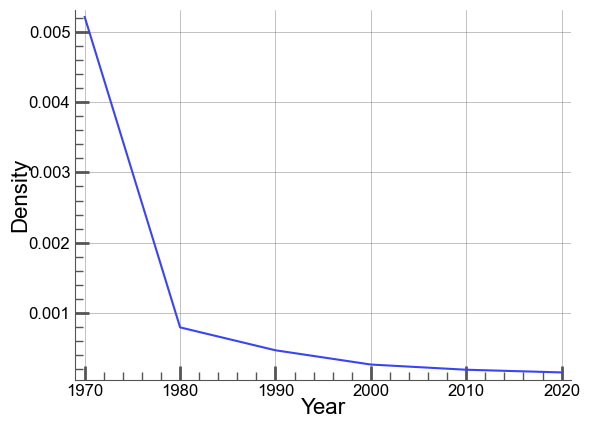

In [45]:
with aquarel.load_theme("scientific"):
    sns.lineplot(x=year_list[1:], y=density_list[1:], color=color_ensta)
    plt.xlabel("Year", fontsize=16)
    plt.ylabel("Density", fontsize=16)
    plt.show()

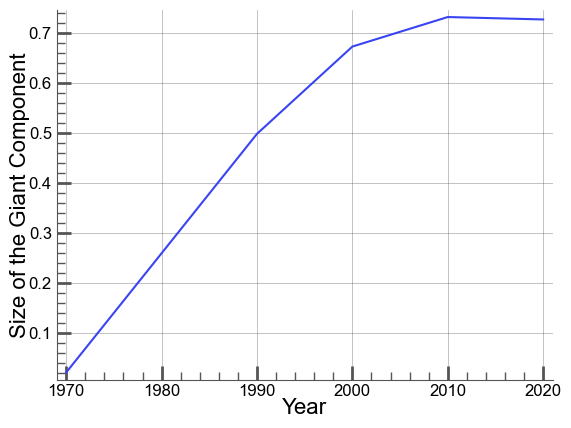

In [44]:
with aquarel.load_theme("scientific"):
    sns.lineplot(x=year_list[1:], y=size_giant_list[1:], color=color_ensta)
    plt.xlabel("Year", fontsize=16)
    plt.ylabel("Size of the Giant Component", fontsize=16)
    plt.show()

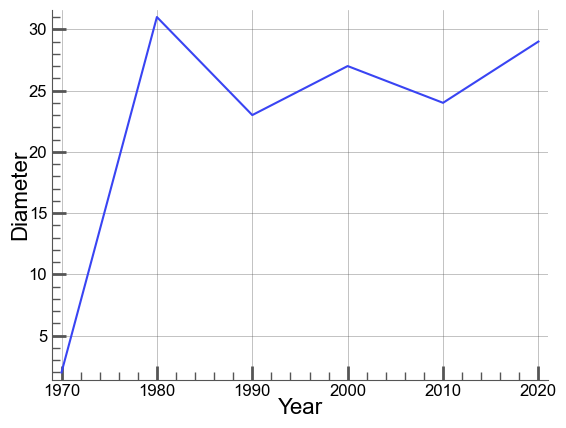

In [43]:
with aquarel.load_theme("scientific"):
    sns.lineplot(x=year_list[1:], y=diameter_list[1:], color=color_ensta)
    plt.xlabel("Year", fontsize=16)
    plt.ylabel("Diameter", fontsize=16)
    plt.show()

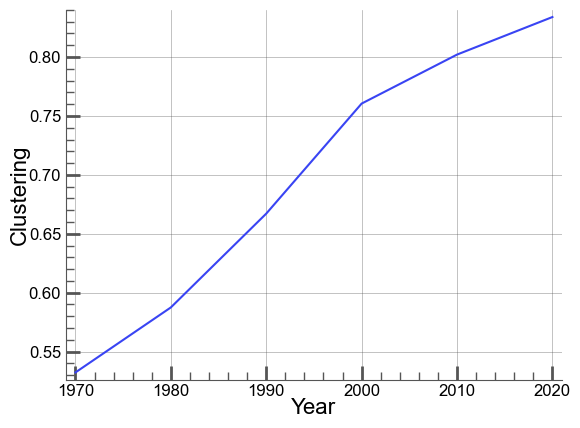

In [42]:
with aquarel.load_theme("scientific"):
    sns.lineplot(x=year_list[1:], y=clustering_list[1:], color=color_ensta)
    plt.xlabel("Year", fontsize=16)
    plt.ylabel("Clustering", fontsize=16)
    plt.show()

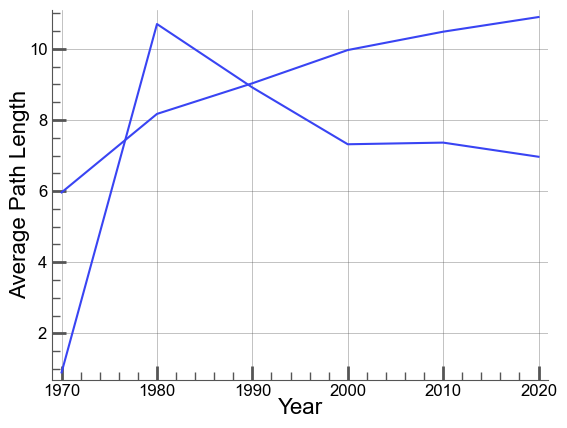

In [47]:
with aquarel.load_theme("scientific"):
    sns.lineplot(x=year_list[1:], y=apl_list[1:], color=color_ensta)
    sns.lineplot(x=year_list[1:], y=np.log(nodes_list[1:]), color=color_ensta)
    plt.xlabel("Year", fontsize=16)
    plt.ylabel("Average Path Length", fontsize=16)
    plt.show()

In [19]:
year_list = []
nodes_list = []
edges_list = []
density_list = []
size_giant_list = []
diameter_list = []
clustering_list = []
apl_list = []

for i in range(1960, 2021, 10):
    partial_edges = edges[edges["Date"]<i]
    partial_graph = nx.from_pandas_edgelist(partial_edges, "Source", "Target")
    giant_nodes = max(nx.connected_components(partial_graph), key=len)
    giant_component = partial_graph.subgraph(giant_nodes).copy()

    nodes_count = partial_graph.number_of_nodes()
    edges_count = partial_graph.number_of_edges()
    density = nx.density(partial_graph)
    size_giant = giant_component.number_of_nodes()
    diameter = nx.approximation.diameter(giant_component)
    clustering = nx.average_clustering(partial_graph)
    apl = approximate_avg_shortest_path_length(partial_graph, num_sources=500, max_targets_per_source=500)

    year_list.append(i)
    nodes_list.append(nodes_count)
    edges_list.append(edges_count)
    density_list.append(density)
    size_giant_list.append(size_giant)
    diameter_list.append(diameter)
    clustering_list.append(clustering)
    apl_list.append(apl)

    print(f"Année {i}")
    print("Nombre de nœuds dans le sous-graphe :", nodes_count)
    print("Nombre d'arêtes dans le sous-graphe :", edges_count)
    print("Densité du sous-graphe :", density)
    print("Taille du plus grand composant connexe :", size_giant)
    print("Diamètre du plus grand composant connexe :", diameter)
    print("Clustering du sous-graphe :", clustering)
    print("Longueur moyenne des plus courts chemins approximatifs :", apl)
    print("\n")

    

Année 1960
Nombre de nœuds dans le sous-graphe : 4
Nombre d'arêtes dans le sous-graphe : 2
Densité du sous-graphe : 0.3333333333333333
Taille du plus grand composant connexe : 2
Diamètre du plus grand composant connexe : 1
Clustering du sous-graphe : 0.0
Longueur moyenne des plus courts chemins approximatifs : 0.5


Année 1970
Nombre de nœuds dans le sous-graphe : 389
Nombre d'arêtes dans le sous-graphe : 393
Densité du sous-graphe : 0.005207643177059868
Taille du plus grand composant connexe : 8
Diamètre du plus grand composant connexe : 2
Clustering du sous-graphe : 0.532256090096707
Longueur moyenne des plus courts chemins approximatifs : 0.9013484740951029


Année 1980
Nombre de nœuds dans le sous-graphe : 3537
Nombre d'arêtes dans le sous-graphe : 4986
Densité du sous-graphe : 0.0007973242144773353
Taille du plus grand composant connexe : 916
Diamètre du plus grand composant connexe : 31
Clustering du sous-graphe : 0.5874423507942602
Longueur moyenne des plus courts chemins approx

In [28]:
for i in range(len(year_list)):
    size_giant_list[i] = size_giant_list[i] / nodes_list[i] 

In [ ]:
def small_world_approx(G, num_sources=100, max_targets=1000):
    # Clustering and path length of our graph
    C = nx.average_clustering(G)
    L = approximate_avg_shortest_path_length(G, num_sources=num_sources, max_targets_per_source=max_targets)

    # Random graph
    n = G.number_of_nodes()
    m = G.number_of_edges()
    G_rand = nx.gnm_random_graph(n, m)
    C_rand = nx.average_clustering(G_rand)
    L_rand = approximate_avg_shortest_path_length(G_rand, num_sources=num_sources, max_targets_per_source=max_targets)

    print(f"Clustering réel C = {C:.4f}, Clustering aléatoire C_rand = {C_rand:.4f}")
    print(f"Avg path length réel L = {L:.4f}, Avg path length aléatoire L_rand = {L_rand:.4f}")

    # Is it a small world ?
    is_small_world = (C > 5*C_rand) and (0.5*L_rand <= L <= 2*L_rand)
    return is_small_world

result = small_world_approx(g, num_sources=500, max_targets=500)
print("Le graphe est-il small-world ?", result)

Clustering réel C = 0.8456, Clustering aléatoire C_rand = 0.0002
Avg path length réel L = 6.8582, Avg path length aléatoire L_rand = 5.1044
Le graphe est-il small-world ? True


## Countries 


In [43]:
edges = pd.read_csv("data/works/edges/correction/edges.csv")

In [44]:
edges.head()

,Source,Target,Type,Country_Source,Country_Target,Date,compteur,now
0,https://openalex.org/A5000001567,https://openalex.org/A5002161190,Undirected,DE,DE,1997,1,2025
1,https://openalex.org/A5000001567,https://openalex.org/A5011241379,Undirected,DE,DE,2003,1,2025
2,https://openalex.org/A5000001567,https://openalex.org/A5017341184,Undirected,DE,CH,2001,1,2025
3,https://openalex.org/A5000001567,https://openalex.org/A5031651406,Undirected,DE,DE,2000,1,2025
4,https://openalex.org/A5000001567,https://openalex.org/A5036622448,Undirected,DE,DE,2009,1,2025


In [45]:
edges = edges[["Country_Source", "Country_Target", "compteur", "Date"]]
edges.columns = ["Source", "Target", "Weight", "Date"]


In [16]:
edges.head()

,Source,Target,Weight,Date
0,DE,DE,1,1997
1,DE,DE,1,2003
2,DE,CH,1,2001
3,DE,DE,1,2000
4,DE,DE,1,2009


In [46]:
edges_country = (
    edges.groupby(by = ["Source", "Target"])
    .agg({
        "Weight":"sum",
        "Date": "mean"
    })
    .reset_index()
)


In [48]:
edges_country.to_csv("data/works/edges/correction/edges_countries.csv", index = False)

In [41]:
g = graphistry.bind(source = "source", destination = "target", edge_weight = "Weight", edge_size = "Weight").edges(edges_country)
g.plot(render = False)

'https://hub.graphistry.com/graph/graph.html?dataset=14c4af3981974144851f3eb0b7136f86&type=arrow&viztoken=c383cad2-57a3-4f4e-a13d-fb6417d6803c&usertag=ac159f01-pygraphistry-0.36.0&splashAfter=1751013722&info=true'